# FDSI benchmark: fixed (no-adaptation) baseline

Runs `AdaptDecomp` forward with every adaptation flag off (`adapt_wh=adapt_sv=adapt_sd=False`) so that the calibrated model is applied to the whole recording but never updated. This is the
no-adaptation reference every tuned config in `04a_pareto_application.ipynb`/
`04b_sv_loss_application.ipynb`/`04c_roa_application.ipynb` is compared against, so any RoA gain
seen there is attributable to adaptation itself rather than to running the model online at all.
Shared across every branch, same reasoning as `01_calibration.ipynb`.

**Load-only by default** (`RUN_CALIBRATION=RUN_DECOMP_FIXED=False`).

## Config

In [1]:
RUN_CALIBRATION = False   # compute missing calibration/<sub>/..._cbss.pkl
RUN_DECOMP_FIXED = False  # compute missing adaptation/<sub>/fixed/..._adapt_fixed.pkl

import yaml
from pathlib import Path

with open('../../configs/data_configs/fdsi_benchmark_grid.yaml') as f:
    grid = yaml.safe_load(f)

DATA_DIR = Path(grid['data_root'])           # Raw archive root: <sub>/{clean,noisy}/
OUTPUTS_ROOT = Path(grid['outputs_root'])    # Precomputed-outputs archive root
CAL_DIR, ADAPT_DIR = OUTPUTS_ROOT / 'calibration', OUTPUTS_ROOT / 'adaptation'
OPT_DIR = ADAPT_DIR / 'optimisation'

FS, EXT_FACT = grid['fs'], grid['ext_fact']
TOL_SPIKE_MS, ROA_CAL_TH = grid['tol_spike_ms'], grid['roa_cal_th']
CAL_END, ISO_DUR = int(grid['cal_duration_s'] * FS), int(grid['iso_duration_s'] * FS)

SUBJECTS, CONDITIONS, SNR_LEVELS = grid['subjects'], grid['conditions'], grid['snr_levels']
TRIANGULAR = [c for c in CONDITIONS if 'triangular' in c]

POOL_CONDITIONS = grid['pool_conditions']
HOLDOUT_CONDITIONS = [c for c in CONDITIONS if c not in POOL_CONDITIONS]
OPTIM_SUB, OPTIM_SNR, N_TRIALS = grid['optim_sub'], grid['optim_snr'], grid['n_trials']

BASE_CONFIG_DIR = Path('../../configs/adapt_configs')
BASE_CONFIG_PATH = BASE_CONFIG_DIR / 'default_muniverse.yaml'   # wh_sv_coupling=True; lr_mode overridden per branch below
LR_TOKEN_TO_MODE = {'lr_fixed': 'fixed', 'lr_relerror': 'rel_error'}

print(f'Apply-to-all grid: {len(SUBJECTS)} subjects x {len(CONDITIONS)} conditions x {len(SNR_LEVELS)} SNR levels '
      f'= {len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS)} recordings')

Apply-to-all grid: 5 subjects x 5 conditions x 4 SNR levels = 100 recordings


## Calibration

Re-derived from the on-disk cache (see `01_calibration.ipynb`) -- `run_fixed` below needs each
recording's `CBSSResult` as input.

In [2]:
import sys
sys.path.insert(0, '../..')          # package root
sys.path.insert(0, str(Path.cwd()))  # this notebook's own directory, for fdsi_common

from typing import Dict, Optional, Tuple
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

import numpy as np
from adapt_decomp import CBSS, CBSSConfig, CBSSResult
from adapt_decomp.utils import load_gt
import fdsi_common as fc


def run_calibration(sub: str, cond: str, snr: int) -> Optional[CBSSResult]:
    """Load this recording's cached calibration, or compute it if RUN_CALIBRATION is True.

    Args:
        sub (str): Subject id.
        cond (str): Condition name.
        snr (int): SNR level in dB.

    Returns:
        Optional[CBSSResult]: The calibration, or None if uncached and not computed, or if
            no unit matched the ground truth above ROA_CAL_TH.
    """
    result_path, config_path = fc.calibration_paths(CAL_DIR, sub, cond, snr)
    if result_path.exists():
        return CBSSResult.load(result_path)
    if not RUN_CALIBRATION:
        return None

    emg_full = fc.load_raw_emg(DATA_DIR, sub, cond, snr)
    emg_calib, ts_calib = emg_full[:CAL_END], np.arange(CAL_END) / FS
    gt_bin = load_gt(fc.gt_spikes_path(DATA_DIR, sub, cond), n_samples=CAL_END)

    cbss_config = CBSSConfig(fs=FS, ext_fact=EXT_FACT, sil_th=0.9, random_seed=42,
                              ica_iter=300, search_iter=300, save_emg=True)
    try:
        result = CBSS(cbss_config).decompose(emg_calib, ts_calib)
        result = result.select_supervised(gt_bin, roa_th=ROA_CAL_TH, tol_spike_ms=TOL_SPIKE_MS, fs=FS)
    except ValueError as exc:
        print(f'  [calibration skipped] {sub} {cond} snr{snr}dB: {exc}')
        return None

    result_path.parent.mkdir(parents=True, exist_ok=True)
    result.save(result_path)
    cbss_config.to_yaml(config_path)
    return result


calibrations: Dict[Tuple[str, str, int], Optional[CBSSResult]] = {}
pbar = tqdm(total=len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS), desc='Calibration')
for sub in SUBJECTS:
    for cond in CONDITIONS:
        for snr in SNR_LEVELS:
            calibrations[(sub, cond, snr)] = run_calibration(sub, cond, snr)
            pbar.update(1)
pbar.close()

n_cal = sum(v is not None for v in calibrations.values())
print(f'Calibration available: {n_cal}/{len(calibrations)} recordings.')

Calibration:   0%|          | 0/100 [00:00<?, ?it/s]

Calibration available: 100/100 recordings.


## Run the no-adaptation baseline on one recording

`AdaptDecomp.from_calibration` builds the online model from a `CBSSResult` + the `CBSSConfig`
that produced it; `process_data` then runs it forward, batch by batch, over the full recording.
With every `adapt_*` flag off, this reproduces the calibrated model applied unchanged -- but
through the same online `AdaptDecomp` path every adaptation config below also uses, so they're all
compared on equal footing. Continuing with `OPTIM_SUB`/`TRIANGULAR[0]`/`OPTIM_SNR` from
`01_calibration.ipynb`.

In [3]:
from adapt_decomp.adaptation import AdaptConfig
from adapt_decomp import AdaptDecomp

sub, cond, snr = OPTIM_SUB, TRIANGULAR[0], OPTIM_SNR
cbss_result = calibrations[(sub, cond, snr)]

# Read back this recording's own CBSSConfig -- ext_fact etc. must match the calibration it came from.
emg_full = fc.load_raw_emg(DATA_DIR, sub, cond, snr)
_, cal_config_path = fc.calibration_paths(CAL_DIR, sub, cond, snr)
cbss_config = CBSSConfig.from_yaml(cal_config_path)

# Initialise adaptation from calibration and apply to the full recording
adapt_config = AdaptConfig(ext_fact=EXT_FACT, adapt_wh=False, adapt_sv=False, adapt_sd=False)
adapter = AdaptDecomp.from_calibration(calibration=cbss_result, cbss_config=cbss_config,
                                        adapt_config=adapt_config)
outputs = adapter.process_data(emg_full, preprocess=True)

# Compute SIL and RoA for the full recording
outputs.sil = fc.get_sil(outputs.sources, outputs.spikes, adapt_config.spike_min_dist, peak_power=adapt_config.spike_det_exp).numpy()
gt_full_bin = fc.load_gt_full_bin(DATA_DIR, sub, cond, cbss_result, n_samples=outputs.spikes.shape[0])
outputs.roa = fc.compute_roa_for_result(outputs, gt_full_bin, FS, TOL_SPIKE_MS)

print(f'{sub} {cond} snr{snr}dB: {int(outputs.spikes.sum())} spikes detected over '
      f'{outputs.spikes.shape[0] / FS:.1f} s (no adaptation).')

sub-01 triangular-ramp40s snr30dB: 7223 spikes detected over 90.0 s (no adaptation).


In [4]:
# CPU without loss calculaion
title = 'No adaptation execution time'
print(title + '\n' + '-'*len(title))
for key in ['preprocess_time_ms', 'wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
    print(f'{key:>19}: {outputs[key].mean():.3f} ± {outputs[key].std():.3f} ms')

No adaptation execution time
----------------------------
 preprocess_time_ms: 0.000 ± 0.000 ms
         wh_time_ms: 7.648 ± 3.696 ms
         sv_time_ms: 0.282 ± 1.159 ms
         sd_time_ms: 0.370 ± 1.378 ms
      total_time_ms: 8.299 ± 4.008 ms


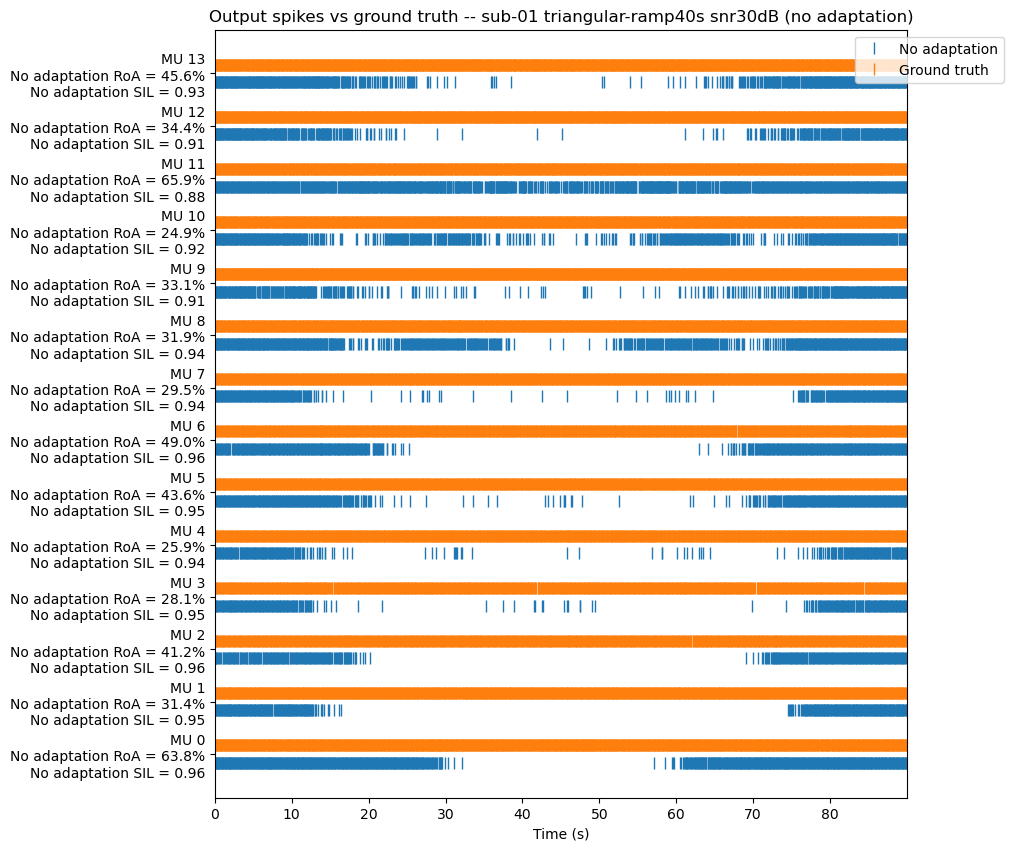

In [5]:
import matplotlib.pyplot as plt

from adapt_decomp.utils.plots import plot_spikes

# Output spikes vs ground truth, over the full recording -- the same pairing as
# 01_calibration.ipynb's calibration-window raster, now over all 90 s with no adaptation.
gt_full_bin = load_gt(fc.gt_spikes_path(DATA_DIR, sub, cond), n_samples=outputs.spikes.shape[0])
ts_full = np.arange(outputs.spikes.shape[0]) / FS

# Zoom window so individual spikes stay legible -- set to None to plot the full recording.
TIME_RANGE = (0, ts_full[-1])  # seconds

ax = plot_spikes(
    spikes={'No adaptation': outputs.spikes.numpy(), 'Ground truth': gt_full_bin[:, cbss_result.gt_matched_indices]},
    timestamps=ts_full,
    time_range=TIME_RANGE,
    roa={'No adaptation': outputs.roa},
    sil={'No adaptation': outputs.sil},
)
ax.set_title(f'Output spikes vs ground truth -- {sub} {cond} snr{snr}dB (no adaptation)')
plt.show()

## Apply the no-adaptation baseline to the full benchmark grid

`run_fixed` below wraps the same call sequence just shown, cached the same way as calibration.

In [6]:
from adapt_decomp import AdaptationResult
from adapt_decomp.spikes import get_sil


def run_fixed(sub: str, cond: str, snr: int,
              cbss_result: Optional[CBSSResult]) -> Optional[AdaptationResult]:
    """Load this recording's cached no-adaptation baseline, or compute it if RUN_DECOMP_FIXED is True.

    Args:
        sub (str): Subject id.
        cond (str): Condition name.
        snr (int): SNR level in dB.
        cbss_result (Optional[CBSSResult]): This recording's calibration, or None if
            calibration itself was skipped.

    Returns:
        Optional[AdaptationResult]: The no-adaptation baseline, or None if uncached/uncomputable.
    """
    if cbss_result is None:
        return None
    result_path, config_path = fc.fixed_paths(ADAPT_DIR, sub, cond, snr)
    if result_path.exists():
        return AdaptationResult.load(result_path)
    if not RUN_DECOMP_FIXED:
        return None

    # Get cbss config
    emg_full = fc.load_raw_emg(DATA_DIR, sub, cond, snr)
    _, cal_config_path = fc.calibration_paths(CAL_DIR, sub, cond, snr)
    cbss_config = CBSSConfig.from_yaml(cal_config_path)

    # Initialise adaptation and apply to the full recording
    adapt_config = AdaptConfig(ext_fact=EXT_FACT, adapt_wh=False, adapt_sv=False, adapt_sd=False)
    adapter = AdaptDecomp.from_calibration(calibration=cbss_result, cbss_config=cbss_config,
                                            adapt_config=adapt_config)
    outputs = adapter.process_data(emg_full, preprocess=True)

    # Compute SIL and RoA for the full recording
    outputs.sil = get_sil(outputs.sources, outputs.spikes, adapt_config.spike_min_dist,
                           peak_power=adapt_config.spike_det_exp).numpy()
    gt_full_bin = fc.load_gt_full_bin(DATA_DIR, sub, cond, cbss_result, n_samples=outputs.spikes.shape[0])
    outputs.roa = fc.compute_roa_for_result(outputs, gt_full_bin, FS, TOL_SPIKE_MS)

    # Save the adaptation result and config
    result_path.parent.mkdir(parents=True, exist_ok=True)
    outputs.save(result_path)
    adapt_config.to_yaml(config_path)
    return outputs


fixed_results: Dict[Tuple[str, str, int], Optional[AdaptationResult]] = {}
for (sub, cond, snr), cal in calibrations.items():
    fixed_results[(sub, cond, snr)] = run_fixed(sub, cond, snr, cal)

n_fixed = sum(v is not None for v in fixed_results.values())
print(f'Fixed baseline available: {n_fixed}/{len(fixed_results)} recordings.')

Fixed baseline available: 100/100 recordings.
